# Transportation Demand Forecast — Results Walkthrough

Tom Bitran · Lee Rosenblit

This notebook is the **presentation layer** over the pipeline's saved artifacts —
per the repo convention, all pipeline logic lives in `src/` (see `README.md` for
the run order; `REPORT.md` for the full write-up). Everything shown here is read
from `models/` and `reports/` exactly as the batch pipeline wrote them, so this
notebook can be re-executed end-to-end in seconds without Spark.

To regenerate the artifacts themselves: `run_pipeline_full_year.bat` (or the
step-by-step commands in the README).

In [1]:
import json, sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Locate the repo root (this notebook lives in notebooks/).
ROOT = Path.cwd()
while not (ROOT / 'config.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

## 1. The trained model — what was fitted, on what

`kmeans_metadata.json` is the model card: chosen K, what each criterion
suggested, the seed, and the exact months the model was fitted on — so a Q1
artifact can never be mistaken for a full-year one.

In [2]:
meta = json.loads(config.KMEANS_METADATA_JSON.read_text())
print('chosen K           :', meta['chosen_k'])
print('elbow suggested    :', meta['k_suggested_by_elbow'])
print('silhouette suggests:', meta['k_suggested_by_silhouette'])
print('criteria agree     :', meta['criteria_agree'])
print('fitted on          :', meta['data_range']['start'], '..', meta['data_range']['end'],
      f"({len(meta['data_range']['months'])} months)")
print('profile matrix     :', meta['profile_shape'][0], 'zones x', meta['profile_shape'][1], 'hours-of-week')
print('seed               :', meta['seed'])
if meta.get('selection_changed'):
    print('note               :', meta['selection_note'])

chosen K           : 5
elbow suggested    : 5
silhouette suggests: 2
criteria agree     : False
fitted on          : 2024-01-01 .. 2024-12-31 (12 months)
profile matrix     : 225 zones x 168 hours-of-week
seed               : 42
note               : K changed from 4 to 5. K=4 was selected on 3 month(s) (2024-01..2024-03); K=5 is selected on 12 month(s) (2024-01..2024-12).


## 2. The five demand-shape clusters

K-Means clusters zones by their L1-normalised weekly profile — *when* a zone is
busy, not how busy. Cluster characters are **derived from the shapes at load
time**, never hand-named.

In [3]:
from src.stream.predict_live import Forecaster

forecaster = Forecaster()
rows = []
for cluster, ch in sorted(forecaster.characters.items()):
    members = forecaster.zones[forecaster.zones['cluster'] == cluster]
    rows.append({
        'cluster': cluster,
        'character': ch['label'],
        'zones': ch['n_zones'],
        'peak hour': ch['peak_label'],
        'total trips (train)': int(members['total_trips'].sum()),
    })
pd.DataFrame(rows).set_index('cluster')

,character,zones,peak hour,total trips (train)
cluster,,,,
0,residential commute — weekday mornings,35,Wed 07:00,625492
1,mixed / low-signal,50,Sat 23:00,379228
2,business core — weekday evenings,66,Thu 18:00,33904824
3,nightlife — weekend small hours,15,Sun 01:00,3876587
4,residential commute — weekday mornings,59,Fri 07:00,410734


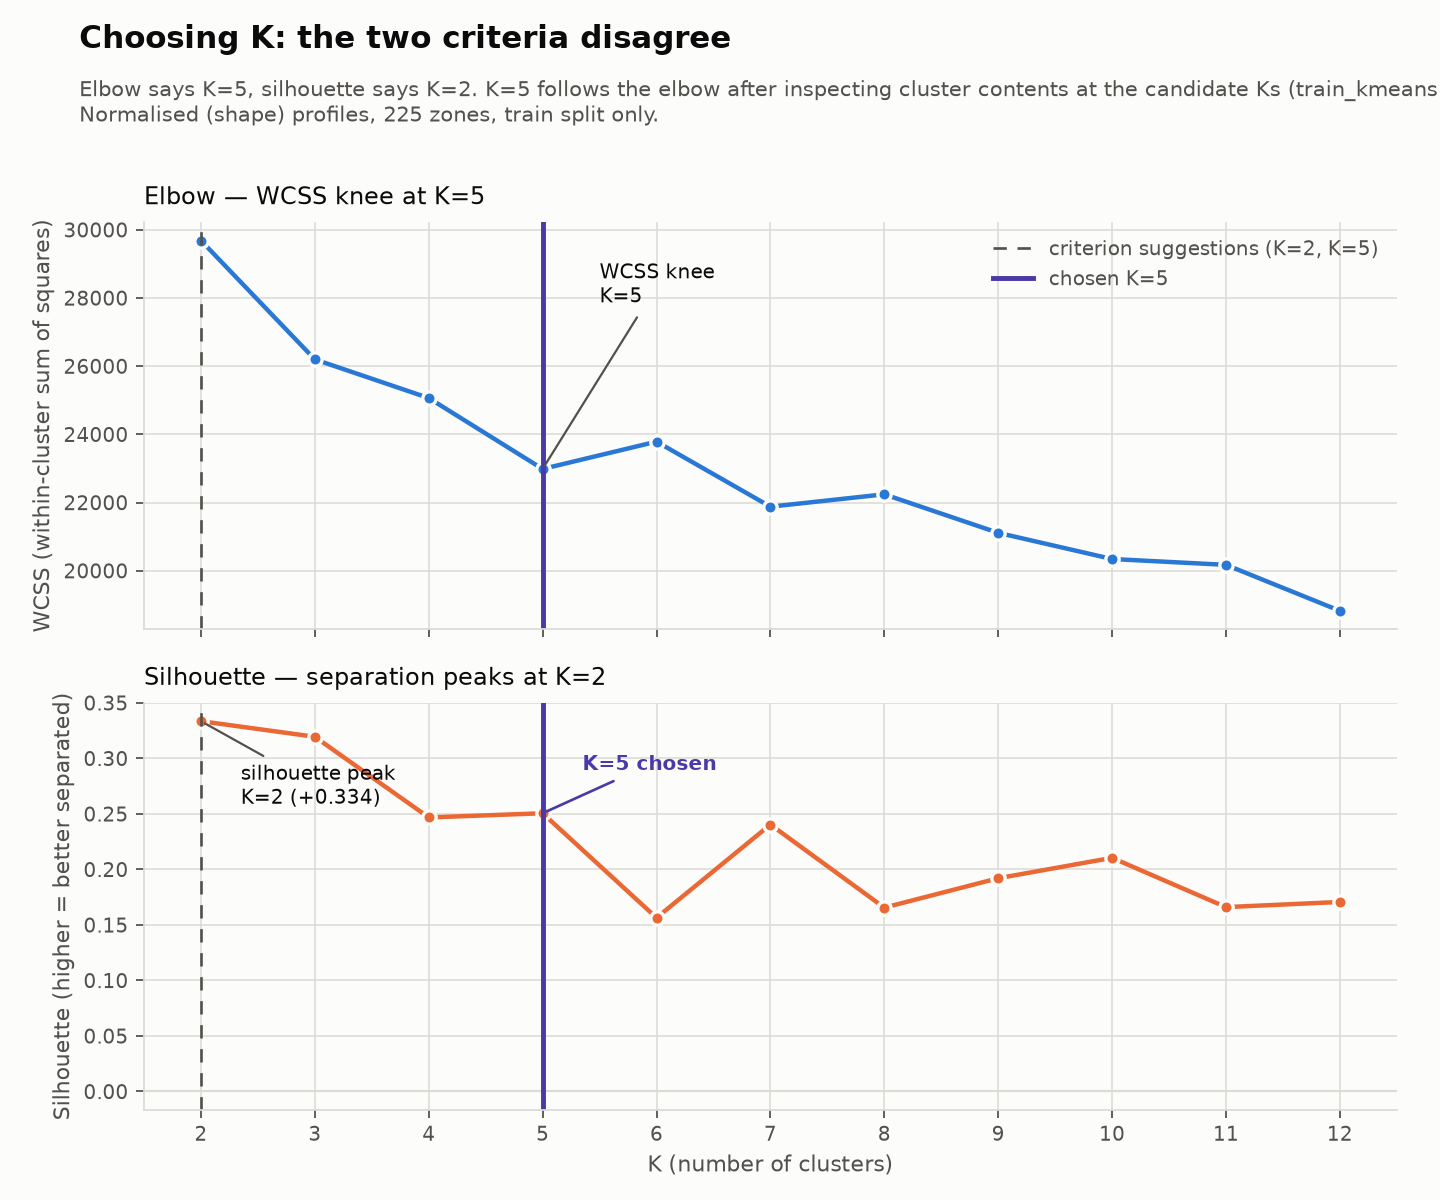

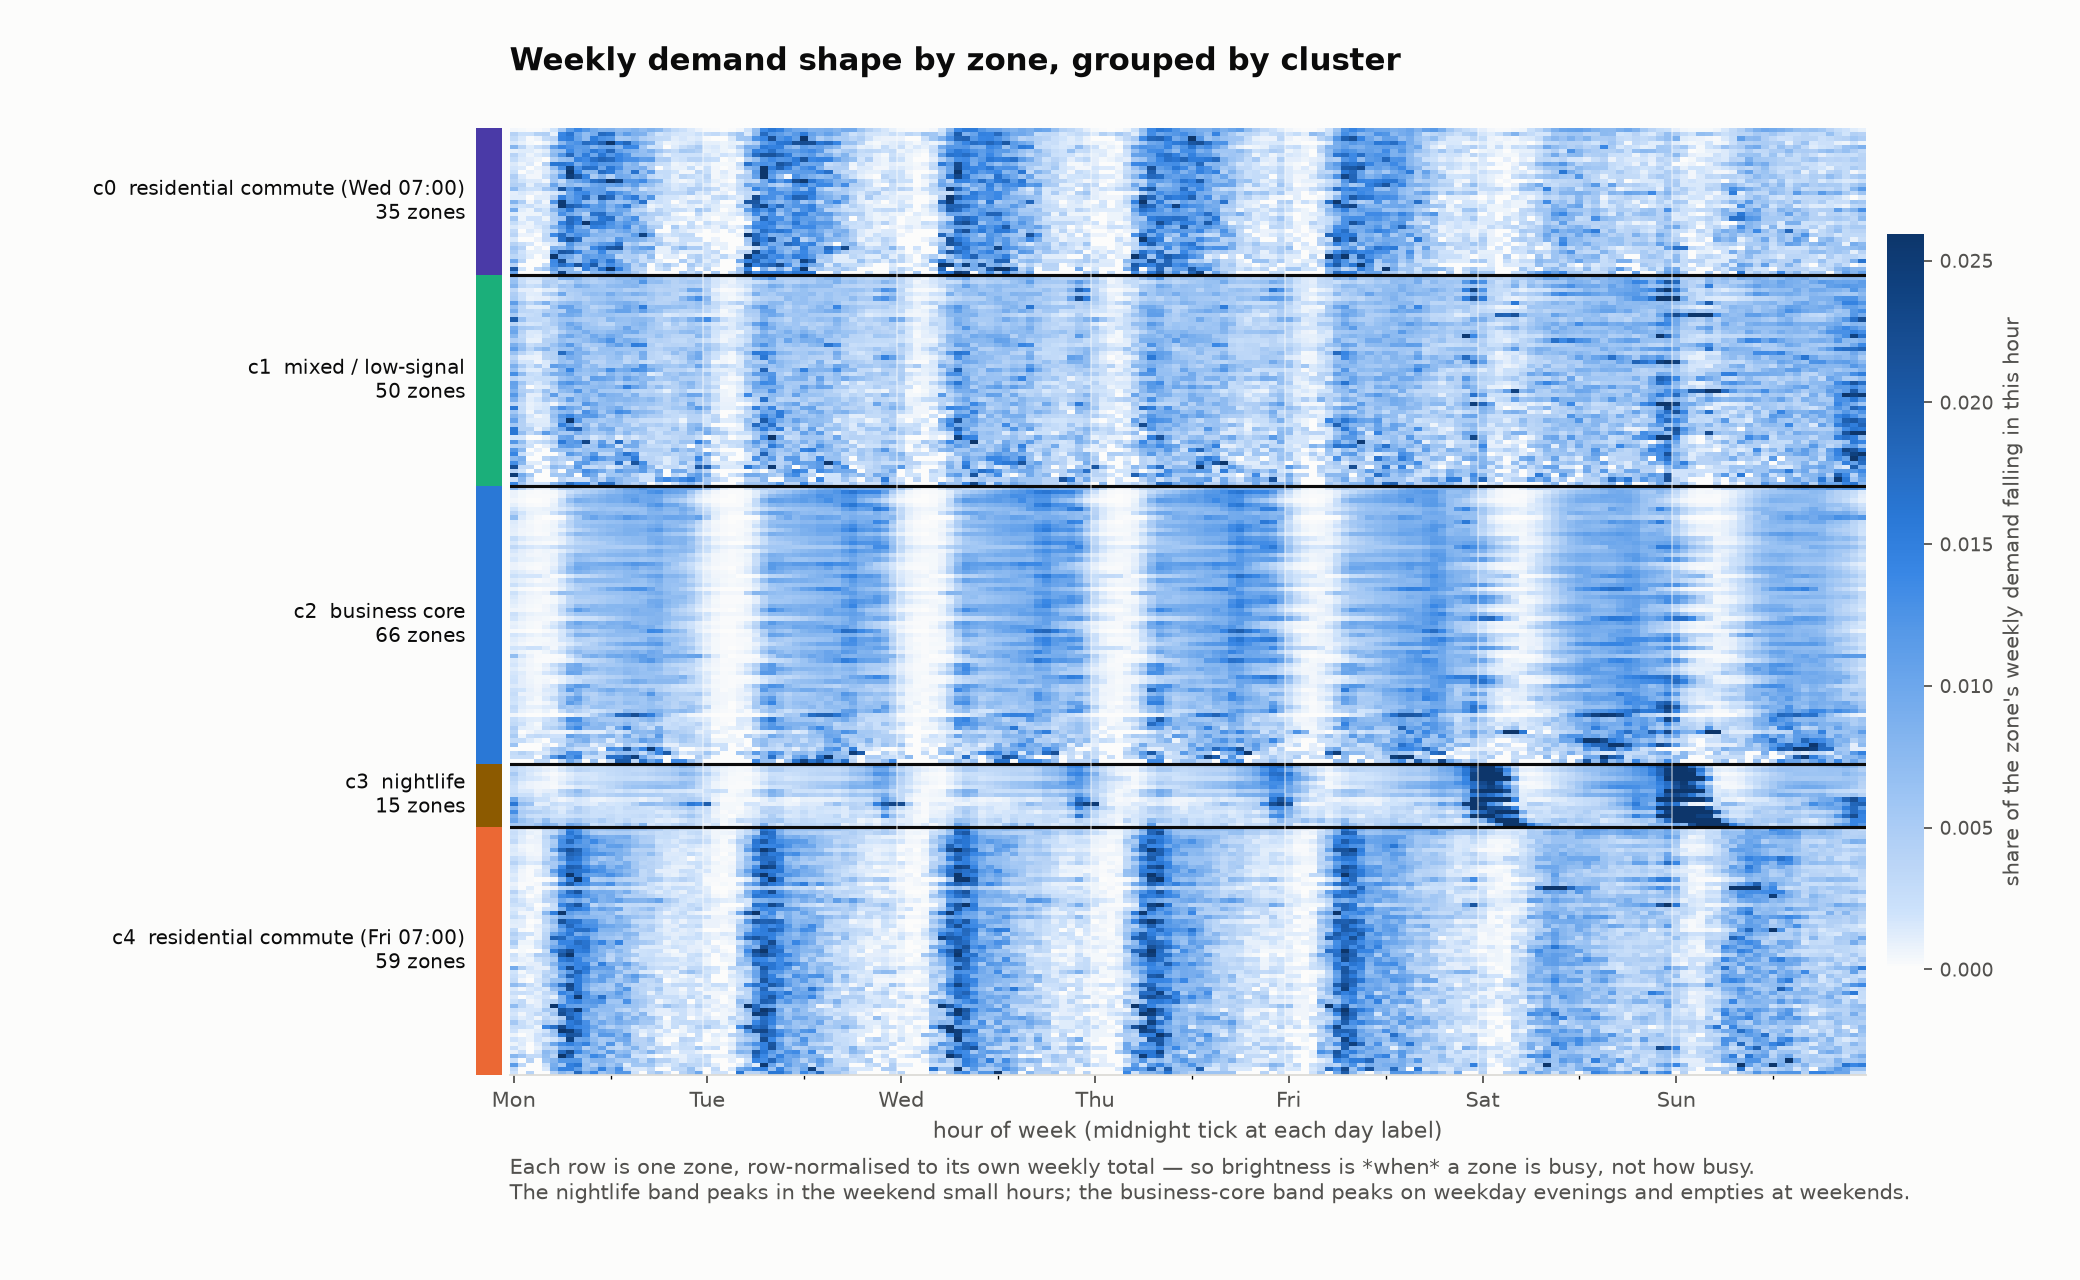

In [4]:
display(Image(filename=str(config.REPORTS_DIR / 'k_selection.png'), width=760))
display(Image(filename=str(config.REPORTS_DIR / 'zone_hour_heatmap.png'), width=860))

## 3. The baseline ladder — where every model stands

All methods scored on the **identical held-out rows** (last ~20% of the year).
WAPE is the headline metric: the grid is ~46% zero bins, where MAPE is
undefined. The moving-average family reads observed demand at inference time —
an information advantage the frozen models don't have, flagged in `evaluate.py`.

In [5]:
ladder = pd.read_csv(config.METRICS_CSV)
ladder = ladder[ladder['subset'] == 'all'].drop(columns=['subset', 'mean_pred'])
ladder['wape %'] = 100 * ladder.pop('wape')
ladder.set_index('method').sort_values('mae')

,n,mae,rmse,mape_nonzero,wape %
method,,,,,
"Moving avg (same hour-of-week, 4w)",399600,5.141,17.633,0.561,24.102
"EWMA (4w, alpha=0.3)",399600,5.279,18.186,0.575,24.749
"Weighted MA (4w, linear)",399600,5.330,18.415,0.580,24.986
"Historical avg (zone,hour,dow)",399600,5.437,18.196,0.512,25.487
Cluster shape x zone level (K-Means),399600,7.587,24.606,0.712,35.565
Per-zone mean,399600,13.464,38.803,1.880,63.117
"Cluster mean (K-Means, raw pooled)",399600,20.223,49.532,3.732,94.800
Global mean (naive floor),399600,31.513,60.405,7.386,147.729


## 4. Open question #2 — do weather & events beat trips-only?

The ablation (`src/batch/ablation.py`): four **nested** feature sets × two
learners, identical split and metrics. Weather/event terms enter as interactions
with `hist_avg_demand`, so their effect is proportional to a cell's usual volume.

In [6]:
ablation = pd.read_csv(config.ABLATION_METRICS_CSV)
wape = (ablation[ablation['learner'] == 'linear']
        .pivot(index='feature_set', columns='subset', values='wape') * 100)
order = ['time only', 'time + weather', 'time + events', 'time + weather + events']
wape = wape.loc[order, ['all', 'rain', 'special']]
wape.columns = ['full grid %', 'rain hours %', 'special days %']
gain = 100 * (wape.loc['time only'] - wape.loc['time + weather + events']) / wape.loc['time only']
print('relative WAPE improvement, full model vs time-only:')
for name, value in gain.items():
    print(f'  {name:<16} {value:+.2f}%')
wape

relative WAPE improvement, full model vs time-only:
  full grid %      +2.46%
  rain hours %     +8.48%
  special days %   +11.18%


,full grid %,rain hours %,special days %
feature_set,,,
time only,25.487,31.222,47.926
time + weather,25.409,30.818,47.984
time + events,24.934,29.056,42.706
time + weather + events,24.860,28.573,42.569


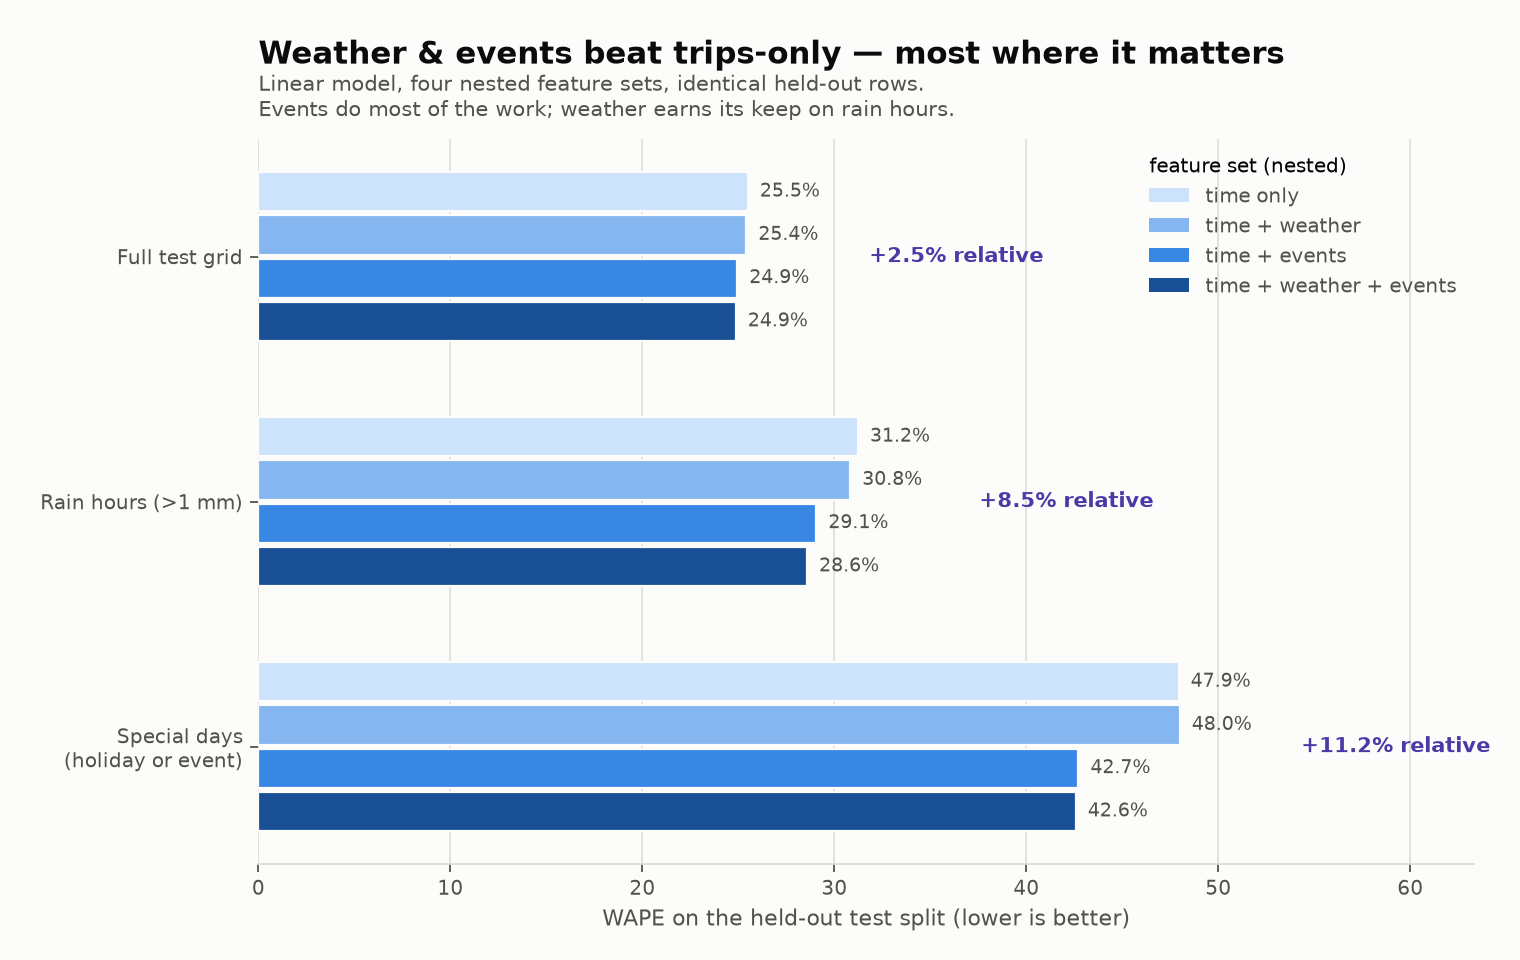

In [7]:
display(Image(filename=str(config.REPORTS_DIR / 'ablation_wape.png'), width=780))

**Verdict: yes, meaningfully** — by the convention stated in the ablation's
output *before* reading the results (≥2% relative overall or ≥5% on a target
subset): **+2.5% overall, +11.2% on special days, +8.5% on rain hours**, and the
GBT learner agrees. The fitted coefficients read plainly: each mm of rain
**+0.55%** of a cell's usual demand; an event day **−8.8%**; a federal holiday
**−24.2%** — events *reduce* street demand on average, which is exactly why
trip history alone overshoots Thanksgiving.

In [8]:
conditions = json.loads(config.CONDITIONS_MODEL_JSON.read_text())
print('exported conditions model:', conditions['learner'])
print('parity vs Spark predictions (max |diff|):', conditions['portable_parity_max_abs_diff'])
interactions = {k: v for k, v in conditions['coefficients'].items() if k.endswith('_x_hist')}
pd.Series(interactions, name='coefficient (fraction of usual demand)').to_frame()

exported conditions model: linear regression (OLS, normal solver), Spark MLlib
parity vs Spark predictions (max |diff|): 1.1368683772161603e-13


,coefficient (fraction of usual demand)
temp_dev_x_hist,-0.000
precip_x_hist,0.005
fedhol_x_hist,-0.242
event_x_hist,-0.088


### Is the improvement statistically real?

`src/batch/significance.py` block-bootstraps **over test days** (errors
correlate within a day, so per-row resampling would overstate certainty;
10,000 replicates, seed 42). Read honestly: the rain-hours improvement is
unambiguous; the overall improvement is significant at the 5% one-sided
level with a CI touching zero; special days have only 6 held-out days, so
the wide CI is the honest cost of a leakage-free time split.

In [9]:
sig = pd.read_csv(config.REPORTS_DIR / 'significance.csv')
sig[['subset', 'n_days', 'wape_hist_pct', 'wape_full_pct',
     'delta_rel_pct', 'ci95_lo', 'ci95_hi', 'p_one_sided']].set_index('subset')

,n_days,wape_hist_pct,wape_full_pct,delta_rel_pct,ci95_lo,ci95_hi,p_one_sided
subset,,,,,,,
all,74,25.487,24.860,2.463,-0.356,5.576,0.045
special_days,6,47.926,42.569,11.178,-20.247,28.271,0.205
rain_hours,19,31.222,28.573,8.484,2.571,18.716,0.000


### Where the model fails

`reports/error_map.html` maps held-out WAPE per zone. The pattern: the dense
Manhattan core forecasts best (~18–20% WAPE); thin residential/edge zones
worst (~40–45%) — spikier demand with the same citywide weather signal.

## 4b. Association rules — FP-Growth over origin→destination flows

A second mining technique alongside clustering. One transaction per cleaned
trip (pickup item + dropoff item), Spark MLlib FP-Growth over all 39.2M
trips. Lift > 1 means the origin *specifically* feeds that destination beyond
its citywide popularity — repositioning structure for a dispatcher.

In [10]:
rules = pd.read_csv(config.REPORTS_DIR / 'association_rules.csv')
print(f'{len(rules)} directed PU->DO rules (support >= 0.1%, confidence >= 5%)')
print('highest-lift airport rule:')
airport = rules[rules['pu_name'].str.contains('Airport')].head(1)
display(airport[['pu_name', 'do_name', 'support', 'confidence', 'lift']])
rules.head(10)[['pu_name', 'do_name', 'support', 'confidence', 'lift']]

65 directed PU->DO rules (support >= 0.1%, confidence >= 5%)
highest-lift airport rule:


,pu_name,do_name,support,confidence,lift
36,LaGuardia Airport,Times Sq/Theatre District,0.002,0.064,2.032


,pu_name,do_name,support,confidence,lift
0,Yorkville East,Lenox Hill East,0.001,0.082,4.051
1,Upper West Side South,Upper West Side North,0.002,0.088,3.995
2,Lenox Hill East,Yorkville East,0.001,0.060,3.945
3,Upper West Side North,Upper West Side South,0.002,0.109,3.899
4,Lincoln Square West,Upper West Side South,0.001,0.102,3.656
5,Yorkville West,Lenox Hill West,0.002,0.094,3.606
6,Upper East Side South,Upper East Side North,0.007,0.147,3.329
7,Upper West Side South,Lincoln Square East,0.003,0.093,3.326
8,Upper East Side North,Upper East Side South,0.006,0.141,3.313
9,Lenox Hill West,Yorkville West,0.001,0.065,3.171


## 4c. Scalability — measured, not asserted

The core batch path (read → production cleaning predicates → hourly
aggregation) timed over growing month windows, after a discarded warm-up.
**14× the rows takes 8× the time** — sub-linear, and nothing ever collects
raw data to the driver, so the execution graph is identical on a cluster.

In [11]:
bench = pd.read_csv(config.REPORTS_DIR / 'scale_benchmark.csv')
bench['Mrows/s'] = (bench['rows_per_second'] / 1e6).round(2)
bench[['months', 'rows_in', 'rows_out', 'seconds', 'Mrows/s', 'machine']]

,months,rows_in,rows_out,seconds,Mrows/s,machine
0,1,2964624,72677,4.120,0.720,"AMD64, 16 cores, local[*]"
1,3,9554778,226703,4.220,2.260,"AMD64, 16 cores, local[*]"
2,6,20332093,484308,7.210,2.820,"AMD64, 16 cores, local[*]"
3,12,41169720,1009226,10.500,3.920,"AMD64, 16 cores, local[*]"


## 5. Live prediction — both novelties, in one query

`predict_live.py` serves two labelled models: the **shape model** (bit-identical
to what the Spark stream serves — verified by `--validate`) and the **conditions
model**, which genuinely uses temperature, rain, and event/holiday flags.
Thanksgiving is flagged **automatically from `events.csv`** — no flag supplied:

In [12]:
import pandas as _pd
when = _pd.Timestamp('2024-11-28 15:00')   # Thanksgiving, 15:00
shape = forecaster.predict(161, when)      # Midtown Center
cond = forecaster.predict_conditions(161, when)
print(f"zone 161 (Midtown Center), {when:%a %Y-%m-%d %H:%M}")
print(f"  shape model (stream-served)   : {shape['predicted_demand_rounded']:8.2f} trips")
print(f"  conditions model              : {cond['predicted_demand_rounded']:8.2f} trips")
print(f"    historical base             : {cond['hist_avg_base']:8.2f}")
print(f"    event adjustment            : {cond['event_delta']:+8.2f}   "
      f"({cond['inputs']['holiday_name']} + {cond['inputs']['event_name']})")
print(f"    weather adjustment          : {cond['weather_delta']:+8.2f}   "
      f"(defaults: {cond['assumed'].get('temp_c', 'given')})")

zone 161 (Midtown Center), Thu 2024-11-28 15:00
  shape model (stream-served)   :   328.54 trips
  conditions model              :   283.01 trips
    historical base             :   413.98
    event adjustment            :  -134.66   (Thanksgiving Day + Macy's Thanksgiving Day Parade)
    weather adjustment          :    +0.95   (defaults: 10.1 (monthly normal for 11))


In [13]:
when = _pd.Timestamp('2024-01-13 01:00')   # Saturday night, East Village
dry = forecaster.predict_conditions(79, when, precip_mm=0.0)
wet = forecaster.predict_conditions(79, when, precip_mm=5.0)
print(f"zone 79 (East Village), {when:%a %H:%M} — nightlife cluster")
print(f"  dry forecast     : {dry['predicted_demand_rounded']:8.2f} trips")
print(f"  5 mm rain        : {wet['predicted_demand_rounded']:8.2f} trips  "
      f"({wet['predicted_demand'] - dry['predicted_demand']:+.2f})")
print('  the shift is the fitted precip coefficient x this cell\'s usual demand —')
print('  a live, condition-aware forecast, not a table lookup.')

zone 79 (East Village), Sat 01:00 — nightlife cluster
  dry forecast     :   545.16 trips
  5 mm rain        :   559.93 trips  (+14.77)
  the shift is the fitted precip coefficient x this cell's usual demand —
  a live, condition-aware forecast, not a table lookup.


## 6. Where everything lives

| What | Where |
| --- | --- |
| Full write-up | `REPORT.md` |
| Run order + design notes | `README.md` |
| Metrics | `reports/baseline_metrics.csv`, `reports/ablation_metrics.csv` |
| Figures & map | `reports/*.png`, `reports/cluster_map.html`, `reports/geojson/` |
| Saved models | `models/` (K-Means pipeline, cluster profiles, conditions model) |
| Streaming demo | `run_demo.bat` (Kafka + Spark Structured Streaming) |